# Machine Translation Benchmark: English → Hindi
### Dataset: IITB English-Hindi Corpus (`cfilt/iitb-english-hindi`)

This notebook benchmarks multiple MT models on the IITB English-Hindi dataset and evaluates them using industry-standard metrics:
- **BLEU** (Bilingual Evaluation Understudy)
- **chrF** (Character n-gram F-score)
- **TER** (Translation Edit Rate)
- **METEOR** (Metric for Evaluation of Translation with Explicit Ordering)
- **BERTScore** (Contextual embedding similarity)

**Models compared:**
1. Helsinki-NLP/opus-mt-en-hi (MarianMT)
2. facebook/nllb-200-distilled-600M (NLLB)
3. facebook/mbart-large-50-many-to-many-mmt (mBART-50)
4. Google Translate API (via deep-translator, free tier)


## 1. Install Dependencies

In [ ]:
# Install all required packages — no custom toolkits or gated models needed
%pip install -q --no-warn-conflicts \
    transformers datasets sacrebleu bert-score sacremoses \
    sentencepiece deep-translator nltk accelerate evaluate

%pip install -q --no-warn-conflicts "numpy>=2.1" "torch>=2.5"

In [1]:
# Read HF token from Kaggle Secrets (set up per the instructions above)
from kaggle_secrets import UserSecretsClient

HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
print("HF_TOKEN loaded from Kaggle Secrets")

HF_TOKEN loaded from Kaggle Secrets


## 2. Load Dataset

In [2]:
from datasets import load_dataset
import random
import numpy as np

# Set seed for reproducibility
random.seed(42)
np.random.seed(42)

data = load_dataset("cfilt/iitb-english-hindi", token=HF_TOKEN)
print(data)

for i in range(3):
    item = data["train"][i]
    print(f"EN : {item['translation']['en']}")
    print(f"HI : {item['translation']['hi']}")
    print("---")

README.md: 0.00B [00:00, ?B/s]

dataset_infos.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/190M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/85.7k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/500k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1659083 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/520 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2507 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['translation'],
        num_rows: 1659083
    })
    validation: Dataset({
        features: ['translation'],
        num_rows: 520
    })
    test: Dataset({
        features: ['translation'],
        num_rows: 2507
    })
})
EN : Give your application an accessibility workout
HI : अपने अनुप्रयोग को पहुंचनीयता व्यायाम का लाभ दें
---
EN : Accerciser Accessibility Explorer
HI : एक्सेर्साइसर पहुंचनीयता अन्वेषक
---
EN : The default plugin layout for the bottom panel
HI : निचले पटल के लिए डिफोल्ट प्लग-इन खाका
---


In [3]:
# Use the test split; subsample for speed (full test set = 2507 examples)
# Increase N_SAMPLES for more robust results (at the cost of compute time)
N_SAMPLES = 200  # set to len(data["test"]) for full evaluation

test_data = data["test"].shuffle(seed=42).select(range(N_SAMPLES))

sources   = [item["translation"]["en"] for item in test_data]  # English source
references = [item["translation"]["hi"] for item in test_data]  # Hindi reference

print(f"Evaluating on {N_SAMPLES} test samples")
print(f"Sample source   : {sources[0]}")
print(f"Sample reference: {references[0]}")

Evaluating on 200 test samples
Sample source   : They never believed he died the way the sheriff concluded.
Sample reference: उन्हें शेरिफ के बताये गये तरीके से मृत्यु पर बिलकुल भी भरोसा नहीं है।


## 3. Metric Utilities

We define a unified `compute_metrics` function that accepts a list of hypotheses and references and returns all metrics in one call.

In [4]:
import sacrebleu
from sacrebleu.metrics import BLEU, CHRF, TER
from bert_score import score as bert_score_fn
import nltk
from nltk.translate.meteor_score import meteor_score
from nltk.tokenize import word_tokenize
import warnings
warnings.filterwarnings("ignore")

nltk.download("wordnet", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("omw-1.4", quiet=True)


def compute_metrics(hypotheses: list[str], references: list[str], 
                    model_name: str = "", compute_bertscore: bool = True) -> dict:
    """
    Compute all MT evaluation metrics.
    
    Args:
        hypotheses : list of model-generated translations
        references : list of reference (ground-truth) translations
        model_name : label used for BERTScore lang detection
        compute_bertscore: set False to skip (slow on CPU)
    
    Returns:
        dict with metric names as keys
    """
    results = {}

    # ---------- BLEU ----------
    # sacrebleu expects [[ref1, ref2, ...]] (list of reference lists)
    bleu = BLEU(tokenize="char")  # char tokenizer works well for Hindi (Devanagari)
    bleu_result = bleu.corpus_score(hypotheses, [references])
    results["BLEU"] = round(bleu_result.score, 2)

    # ---------- chrF ----------
    chrf = CHRF(word_order=2)  # chrF++ (word_order=2)
    chrf_result = chrf.corpus_score(hypotheses, [references])
    results["chrF++"] = round(chrf_result.score, 2)

    # ---------- TER ----------
    ter = TER()
    try:
        ter_result = ter.corpus_score(hypotheses, [references])
        results["TER"] = round(ter_result.score, 2)  # lower is better
    except Exception:
        results["TER"] = None

    # ---------- METEOR ----------
    meteor_scores = []
    for hyp, ref in zip(hypotheses, references):
        try:
            score = meteor_score(
                [word_tokenize(ref)],
                word_tokenize(hyp)
            )
            meteor_scores.append(score)
        except Exception:
            meteor_scores.append(0.0)
    results["METEOR"] = round(np.mean(meteor_scores) * 100, 2)

    # ---------- BERTScore ----------
    if compute_bertscore:
        try:
            P, R, F1 = bert_score_fn(
                hypotheses, references,
                lang="hi",
                model_type="bert-base-multilingual-cased",
                verbose=False,
                batch_size=16
            )
            results["BERTScore-F1"] = round(F1.mean().item() * 100, 2)
        except Exception as e:
            print(f"  BERTScore failed: {e}")
            results["BERTScore-F1"] = None
    else:
        results["BERTScore-F1"] = None

    return results


print("Metric utilities ready.")
print("Metrics: BLEU | chrF++ | TER (↓) | METEOR | BERTScore-F1")

Metric utilities ready.
Metrics: BLEU | chrF++ | TER (↓) | METEOR | BERTScore-F1


## 4. Model 1 — Helsinki-NLP/opus-mt-en-hi (MarianMT)

A lightweight, fast neural MT model trained on OPUS data. Often used as a strong baseline for en→hi translation.

In [5]:
from transformers import MarianMTModel, MarianTokenizer
import torch
from tqdm.auto import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

MARIAN_MODEL_NAME = "Helsinki-NLP/opus-mt-en-hi"

print(f"Loading {MARIAN_MODEL_NAME} ...")
marian_tokenizer = MarianTokenizer.from_pretrained(MARIAN_MODEL_NAME)
marian_model = MarianMTModel.from_pretrained(MARIAN_MODEL_NAME).to(device)
marian_model.eval()
print("Model loaded.")


def translate_marian(texts: list[str], batch_size: int = 32) -> list[str]:
    translations = []
    for i in tqdm(range(0, len(texts), batch_size), desc="MarianMT"):
        batch = texts[i : i + batch_size]
        inputs = marian_tokenizer(
            batch, return_tensors="pt", padding=True,
            truncation=True, max_length=512
        ).to(device)
        with torch.no_grad():
            output_ids = marian_model.generate(**inputs, num_beams=4, max_length=512)
        decoded = marian_tokenizer.batch_decode(output_ids, skip_special_tokens=True)
        translations.extend(decoded)
    return translations


marian_hypotheses = translate_marian(sources)
print("\nSample translations:")
for src, hyp, ref in zip(sources[:3], marian_hypotheses[:3], references[:3]):
    print(f"  SRC : {src}")
    print(f"  HYP : {hyp}")
    print(f"  REF : {ref}")
    print()

Using device: cuda
Loading Helsinki-NLP/opus-mt-en-hi ...


tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/812k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Model loaded.


MarianMT:   0%|          | 0/7 [00:00<?, ?it/s]


Sample translations:
  SRC : They never believed he died the way the sheriff concluded.
  HYP : उन्होंने कभी विश्वास नहीं किया कि वह जिस तरह से प्रधान की मृत्यु हुई.
  REF : उन्हें शेरिफ के बताये गये तरीके से मृत्यु पर बिलकुल भी भरोसा नहीं है।

  SRC : People crowded the jewellery shops in Simla.
  HYP : लोग सीला में रत्न की दुकानों में भीड़ - भाड़ में आते हैं ।
  REF : शिमला में आभूषणों की दुकानों में लोंगों का हुजूम लगा रहा।

  SRC : Many on Wall Street view the addition of baggage fees as a sign that airlines are charging enough money to cover the cost of air travel after years of losses.
  HYP : इसके अलावा, कई लोगों को लगता है कि माल खरीदने के लिए पैसा ही काफी होता है ।
  REF : वॉल स्ट्रीट पर  बैगेज की फीस एक संकेत के रूप में कई देख रहे हैं कि कई एयरलाइन घाटे के वर्षों के बाद हवाई यात्रा की लागत को कवर करने के लिए पर्याप्त पैसे चार्ज कर रहे हैं.



In [6]:
print("Computing metrics for MarianMT...")
marian_metrics = compute_metrics(marian_hypotheses, references, model_name="MarianMT")
print("MarianMT Results:")
for k, v in marian_metrics.items():
    print(f"  {k}: {v}")

Computing metrics for MarianMT...


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


MarianMT Results:
  BLEU: 35.5
  chrF++: 30.72
  TER: 83.15
  METEOR: 28.56
  BERTScore-F1: 78.92


## 5. Model 2 — facebook/nllb-200-distilled-600M (NLLB)

Meta's No Language Left Behind model, supporting 200 languages. We use the distilled 600M version for efficiency.

In [8]:
from transformers import AutoModelForSeq2SeqLM, NllbTokenizer

NLLB_MODEL_NAME = "facebook/nllb-200-distilled-600M"
SRC_LANG = "eng_Latn"   # English
TGT_LANG = "hin_Deva"   # Hindi (Devanagari)

print(f"Loading {NLLB_MODEL_NAME} ...")
nllb_tokenizer = NllbTokenizer.from_pretrained(NLLB_MODEL_NAME, src_lang=SRC_LANG)
nllb_model = AutoModelForSeq2SeqLM.from_pretrained(NLLB_MODEL_NAME).to(device)
nllb_model.eval()
print("Model loaded.")


def translate_nllb(texts: list[str], batch_size: int = 16) -> list[str]:
    translations = []
    for i in tqdm(range(0, len(texts), batch_size), desc="NLLB"):
        batch = texts[i : i + batch_size]
        inputs = nllb_tokenizer(
            batch, return_tensors="pt", padding=True,
            truncation=True, max_length=512
        ).to(device)
        forced_bos = nllb_tokenizer.convert_tokens_to_ids(TGT_LANG)
        with torch.no_grad():
            output_ids = nllb_model.generate(
                **inputs,
                forced_bos_token_id=forced_bos,
                num_beams=4,
                max_length=512
            )
        decoded = nllb_tokenizer.batch_decode(output_ids, skip_special_tokens=True)
        translations.extend(decoded)
    return translations


nllb_hypotheses = translate_nllb(sources)
print("\nSample translations:")
for src, hyp, ref in zip(sources[:3], nllb_hypotheses[:3], references[:3]):
    print(f"  SRC : {src}")
    print(f"  HYP : {hyp}")
    print(f"  REF : {ref}")
    print()

Loading facebook/nllb-200-distilled-600M ...


sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Model loaded.


NLLB:   0%|          | 0/13 [00:00<?, ?it/s]


Sample translations:
  SRC : They never believed he died the way the sheriff concluded.
  HYP : उन्होंने कभी भी विश्वास नहीं किया कि वह मर गया है जैसा कि शेरिफ ने निष्कर्ष निकाला।
  REF : उन्हें शेरिफ के बताये गये तरीके से मृत्यु पर बिलकुल भी भरोसा नहीं है।

  SRC : People crowded the jewellery shops in Simla.
  HYP : सिमला में आभूषण की दुकानों में भीड़ थी।
  REF : शिमला में आभूषणों की दुकानों में लोंगों का हुजूम लगा रहा।

  SRC : Many on Wall Street view the addition of baggage fees as a sign that airlines are charging enough money to cover the cost of air travel after years of losses.
  HYP : वॉल स्ट्रीट में कई लोग सामान शुल्क को जोड़ने को इस बात का संकेत मानते हैं कि एयरलाइनें वर्षों के नुकसान के बाद हवाई यात्रा की लागत को कवर करने के लिए पर्याप्त धन वसूल रही हैं।
  REF : वॉल स्ट्रीट पर  बैगेज की फीस एक संकेत के रूप में कई देख रहे हैं कि कई एयरलाइन घाटे के वर्षों के बाद हवाई यात्रा की लागत को कवर करने के लिए पर्याप्त पैसे चार्ज कर रहे हैं.



In [9]:
print("Computing metrics for NLLB...")
nllb_metrics = compute_metrics(nllb_hypotheses, references, model_name="NLLB")
print("NLLB Results:")
for k, v in nllb_metrics.items():
    print(f"  {k}: {v}")

Computing metrics for NLLB...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


NLLB Results:
  BLEU: 56.2
  chrF++: 48.11
  TER: 62.52
  METEOR: 48.02
  BERTScore-F1: 85.85


## 6. Model 3 — facebook/mbart-large-50-many-to-many-mmt (mBART-50)

Meta's mBART-50 is a multilingual seq2seq model pre-trained on 50 languages including Hindi (`hi_IN`). It is **fully public** — no HuggingFace token, no license agreement, no external toolkit. Just standard `transformers`.

It is a strong en→hi baseline and a direct upgrade over MarianMT for morphologically rich target languages like Hindi.


In [10]:
from transformers import MBartForConditionalGeneration, MBart50TokenizerFast

MBART_MODEL_NAME = "facebook/mbart-large-50-many-to-many-mmt"

print(f"Loading {MBART_MODEL_NAME} ...")
mbart_tokenizer = MBart50TokenizerFast.from_pretrained(MBART_MODEL_NAME)
mbart_tokenizer.src_lang = "en_XX"
mbart_model = MBartForConditionalGeneration.from_pretrained(MBART_MODEL_NAME).to(device)
mbart_model.eval()
print("Model loaded.")

HI_LANG_ID = mbart_tokenizer.lang_code_to_id["hi_IN"]


def translate_mbart(texts: list[str], batch_size: int = 16) -> list[str]:
    translations = []
    for i in tqdm(range(0, len(texts), batch_size), desc="mBART-50"):
        batch = texts[i : i + batch_size]
        inputs = mbart_tokenizer(
            batch, return_tensors="pt", padding=True,
            truncation=True, max_length=512
        ).to(device)
        with torch.no_grad():
            output_ids = mbart_model.generate(
                **inputs,
                forced_bos_token_id=HI_LANG_ID,
                num_beams=4,
                max_length=512
            )
        decoded = mbart_tokenizer.batch_decode(output_ids, skip_special_tokens=True)
        translations.extend(decoded)
    return translations


mbart_hypotheses = translate_mbart(sources)
print("\nSample translations:")
for src, hyp, ref in zip(sources[:3], mbart_hypotheses[:3], references[:3]):
    print(f"  SRC : {src}")
    print(f"  HYP : {hyp}")
    print(f"  REF : {ref}")
    print()

Loading facebook/mbart-large-50-many-to-many-mmt ...


tokenizer_config.json:   0%|          | 0.00/529 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/649 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/516 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/261 [00:00<?, ?B/s]

Model loaded.


mBART-50:   0%|          | 0/13 [00:00<?, ?it/s]


Sample translations:
  SRC : They never believed he died the way the sheriff concluded.
  HYP : वे कभी भी ऐसा नहीं मानते थे कि वे शेरीफ के अनुसार मर गये थे।
  REF : उन्हें शेरिफ के बताये गये तरीके से मृत्यु पर बिलकुल भी भरोसा नहीं है।

  SRC : People crowded the jewellery shops in Simla.
  HYP : लोगों ने सिमला के रत्न दुकानों में भीड़ भरी।
  REF : शिमला में आभूषणों की दुकानों में लोंगों का हुजूम लगा रहा।

  SRC : Many on Wall Street view the addition of baggage fees as a sign that airlines are charging enough money to cover the cost of air travel after years of losses.
  HYP : वॉल स्ट्रीट में बहुत से लोग बैगेज फीस की वृद्धि को इस संकेत के रूप में देखते हैं कि एयरलाइनों ने वर्षों के नुकसान के बाद हवाई यात्रा की लागत को पूरा करने के लिए पर्याप्त पैसे खर्च कर रहे हैं।
  REF : वॉल स्ट्रीट पर  बैगेज की फीस एक संकेत के रूप में कई देख रहे हैं कि कई एयरलाइन घाटे के वर्षों के बाद हवाई यात्रा की लागत को कवर करने के लिए पर्याप्त पैसे चार्ज कर रहे हैं.



In [11]:
print("Computing metrics for mBART-50...")
mbart_metrics = compute_metrics(mbart_hypotheses, references, model_name="mBART-50")
print("mBART-50 Results:")
for k, v in mbart_metrics.items():
    print(f"  {k}: {v}")

Computing metrics for mBART-50...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


mBART-50 Results:
  BLEU: 48.12
  chrF++: 41.53
  TER: 77.91
  METEOR: 40.6
  BERTScore-F1: 83.86


## 7. Model 4 — Google Translate (free tier via deep-translator)

Google Translate is a strong commercial baseline. We use the `deep-translator` library (no API key required for small volumes).

⚠️ **Rate limiting**: Google may throttle requests. The code includes a delay; for large samples consider batching or using the official Cloud Translation API.

In [12]:
from deep_translator import GoogleTranslator
import time

def translate_google(texts: list[str], delay: float = 0.3) -> list[str]:
    translator = GoogleTranslator(source="en", target="hi")
    translations = []
    for i, text in enumerate(tqdm(texts, desc="Google Translate")):
        try:
            result = translator.translate(text)
            translations.append(result if result else "")
        except Exception as e:
            print(f"  Error at index {i}: {e}")
            translations.append("")
        if delay:
            time.sleep(delay)
    return translations


google_hypotheses = translate_google(sources)
print("\nSample translations:")
for src, hyp, ref in zip(sources[:3], google_hypotheses[:3], references[:3]):
    print(f"  SRC : {src}")
    print(f"  HYP : {hyp}")
    print(f"  REF : {ref}")
    print()

Google Translate:   0%|          | 0/200 [00:00<?, ?it/s]


Sample translations:
  SRC : They never believed he died the way the sheriff concluded.
  HYP : जिस तरह से शेरिफ ने निष्कर्ष निकाला, उन्होंने कभी विश्वास नहीं किया कि वह मर गया।
  REF : उन्हें शेरिफ के बताये गये तरीके से मृत्यु पर बिलकुल भी भरोसा नहीं है।

  SRC : People crowded the jewellery shops in Simla.
  HYP : शिमला में आभूषणों की दुकानों पर लोगों की भीड़ उमड़ पड़ी।
  REF : शिमला में आभूषणों की दुकानों में लोंगों का हुजूम लगा रहा।

  SRC : Many on Wall Street view the addition of baggage fees as a sign that airlines are charging enough money to cover the cost of air travel after years of losses.
  HYP : वॉल स्ट्रीट पर कई लोग सामान शुल्क में बढ़ोतरी को एक संकेत के रूप में देखते हैं कि एयरलाइंस वर्षों के घाटे के बाद हवाई यात्रा की लागत को कवर करने के लिए पर्याप्त पैसा ले रही हैं।
  REF : वॉल स्ट्रीट पर  बैगेज की फीस एक संकेत के रूप में कई देख रहे हैं कि कई एयरलाइन घाटे के वर्षों के बाद हवाई यात्रा की लागत को कवर करने के लिए पर्याप्त पैसे चार्ज कर रहे हैं.



In [13]:
print("Computing metrics for Google Translate...")
google_metrics = compute_metrics(google_hypotheses, references, model_name="Google")
print("Google Translate Results:")
for k, v in google_metrics.items():
    print(f"  {k}: {v}")

Computing metrics for Google Translate...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Google Translate Results:
  BLEU: 60.0
  chrF++: 52.07
  TER: 57.7
  METEOR: 51.97
  BERTScore-F1: 87.25


## 8. Aggregate Results & Comparison

In [14]:
import pandas as pd

all_results = {
    "MarianMT (Helsinki)": marian_metrics,
    "NLLB-600M (Meta)": nllb_metrics,
    "mBART-50 (Meta)": mbart_metrics,
    "Google Translate": google_metrics,
}

results_df = pd.DataFrame(all_results).T
results_df.index.name = "Model"

# Highlight best (max for BLEU/chrF/METEOR/BERTScore, min for TER)
print("=" * 80)
print(" MT BENCHMARK RESULTS — English → Hindi (IITB Test Set) ")
print("=" * 80)
print(results_df.to_string())
print()
print("Note: TER (↓ lower is better). All other metrics: higher is better.")

 MT BENCHMARK RESULTS — English → Hindi (IITB Test Set) 
                      BLEU  chrF++    TER  METEOR  BERTScore-F1
Model                                                          
MarianMT (Helsinki)  35.50   30.72  83.15   28.56         78.92
NLLB-600M (Meta)     56.20   48.11  62.52   48.02         85.85
mBART-50 (Meta)      48.12   41.53  77.91   40.60         83.86
Google Translate     60.00   52.07  57.70   51.97         87.25

Note: TER (↓ lower is better). All other metrics: higher is better.


## 9. Visualisations

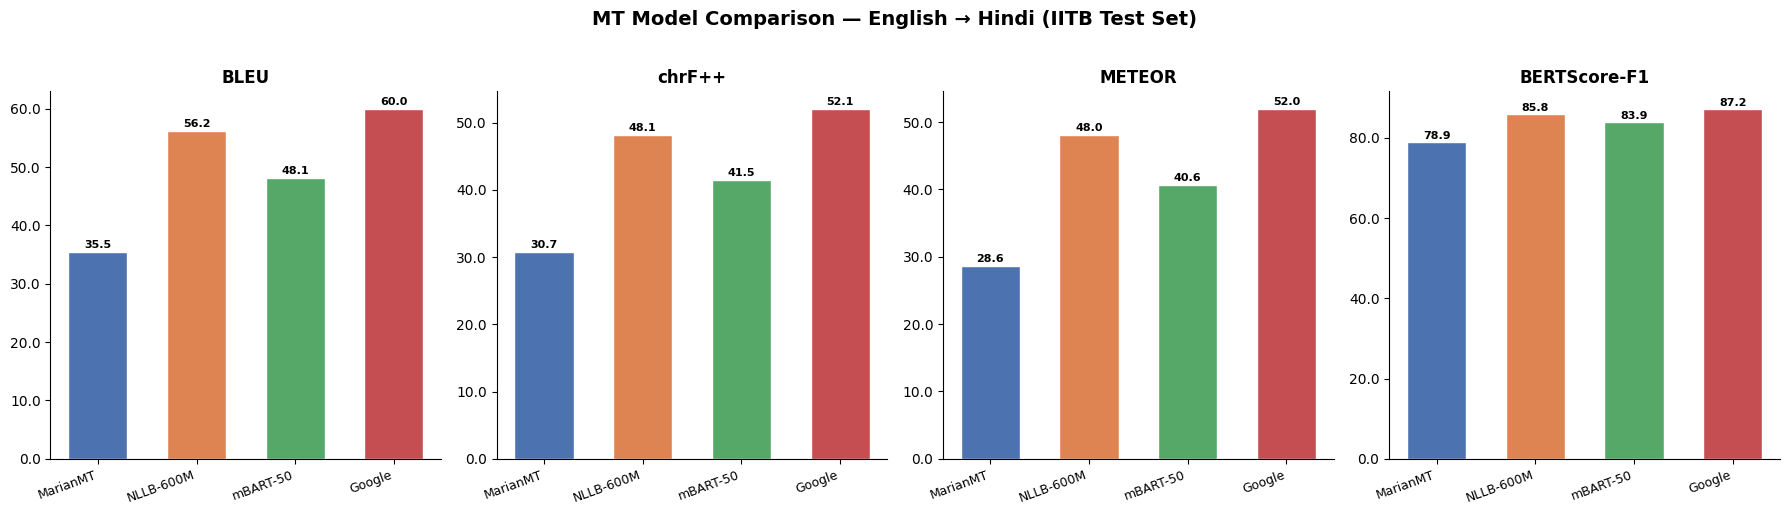

Saved: mt_metrics_comparison.png


In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

models = list(all_results.keys())
metrics_to_plot = ["BLEU", "chrF++", "METEOR", "BERTScore-F1"]  # TER plotted separately
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(18, 5))
fig.suptitle("MT Model Comparison — English → Hindi (IITB Test Set)",
             fontsize=14, fontweight="bold", y=1.02)

for ax, metric in zip(axes, metrics_to_plot):
    values = [all_results[m].get(metric) for m in models]
    bars = ax.bar(range(len(models)), values, color=colors, edgecolor="white", width=0.6)
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels([m.split(" ")[0] for m in models], rotation=20, ha="right", fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
    ax.spines[["top", "right"]].set_visible(False)
    for bar, val in zip(bars, values):
        if val is not None:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                    f"{val:.1f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.savefig("mt_metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: mt_metrics_comparison.png")

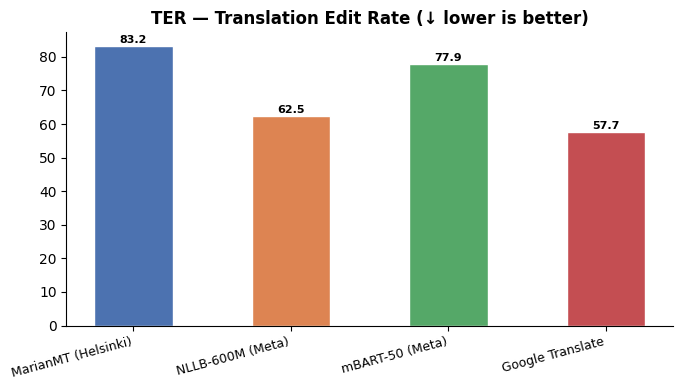

In [16]:
# TER plot separately (lower is better)
ter_values = [all_results[m].get("TER") for m in models]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(range(len(models)), ter_values, color=colors, edgecolor="white", width=0.5)
ax.set_title("TER — Translation Edit Rate (↓ lower is better)",
             fontsize=12, fontweight="bold")
ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=15, ha="right", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
for bar, val in zip(bars, ter_values):
    if val is not None:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f"{val:.1f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
plt.tight_layout()
plt.savefig("mt_ter_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

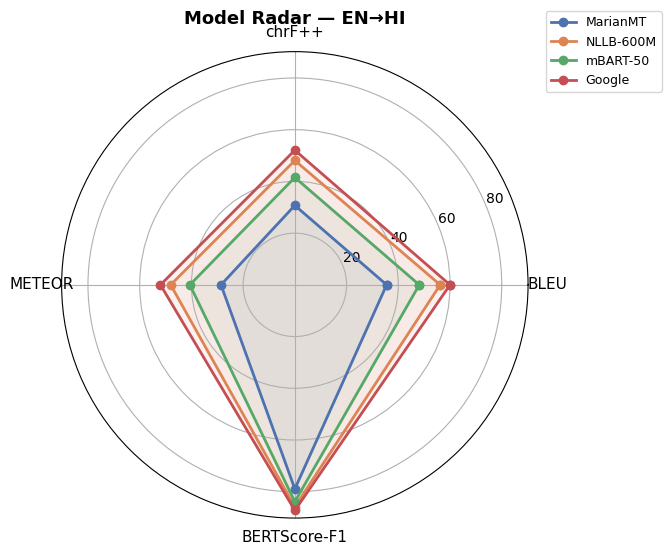

In [17]:
# Radar chart for overall model profiles
import matplotlib.pyplot as plt
import numpy as np

radar_metrics = ["BLEU", "chrF++", "METEOR", "BERTScore-F1"]
n = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
angles += angles[:1]  # close polygon

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for (model, metrics), color in zip(all_results.items(), colors):
    vals = [metrics.get(m, 0) or 0 for m in radar_metrics]
    # Normalise to [0,1] across models for each metric for fair radar comparison
    vals += vals[:1]
    ax.plot(angles, vals, "o-", linewidth=2, label=model.split(" ")[0], color=color)
    ax.fill(angles, vals, alpha=0.07, color=color)

ax.set_thetagrids(np.degrees(angles[:-1]), radar_metrics, fontsize=11)
ax.set_title("Model Radar — EN→HI", fontsize=13, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=9)
plt.tight_layout()
plt.savefig("mt_radar_chart.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Per-Sample Error Analysis

Identify the samples where each model performs best and worst based on sentence-level BLEU.

In [18]:
from sacrebleu.metrics import BLEU

sent_bleu = BLEU(tokenize="char", effective_order=True)

def sentence_bleu_scores(hypotheses, references):
    """Return per-sentence BLEU scores."""
    scores = []
    for h, r in zip(hypotheses, references):
        result = sent_bleu.sentence_score(h, [r])
        scores.append(result.score)
    return scores


model_hyps = {
    "MarianMT": marian_hypotheses,
    "NLLB": nllb_hypotheses,
    "mBART-50": mbart_hypotheses,
    "GoogleTranslate": google_hypotheses,
}

per_sentence_df = pd.DataFrame({"source": sources, "reference": references})
for model, hyps in model_hyps.items():
    per_sentence_df[f"{model}_hyp"] = hyps
    per_sentence_df[f"{model}_bleu"] = sentence_bleu_scores(hyps, references)

per_sentence_df.head(5)

,source,reference,MarianMT_hyp,MarianMT_bleu,NLLB_hyp,NLLB_bleu,mBART-50_hyp,mBART-50_bleu,GoogleTranslate_hyp,GoogleTranslate_bleu
0,They never believed he died the way the sherif...,उन्हें शेरिफ के बताये गये तरीके से मृत्यु पर ब...,उन्होंने कभी विश्वास नहीं किया कि वह जिस तरह स...,22.551666,उन्होंने कभी भी विश्वास नहीं किया कि वह मर गया...,17.974106,वे कभी भी ऐसा नहीं मानते थे कि वे शेरीफ के अनु...,18.835065,"जिस तरह से शेरिफ ने निष्कर्ष निकाला, उन्होंने ...",17.351701
1,People crowded the jewellery shops in Simla.,शिमला में आभूषणों की दुकानों में लोंगों का हुज...,लोग सीला में रत्न की दुकानों में भीड़ - भाड़ म...,37.315678,सिमला में आभूषण की दुकानों में भीड़ थी।,43.309486,लोगों ने सिमला के रत्न दुकानों में भीड़ भरी।,28.796290,शिमला में आभूषणों की दुकानों पर लोगों की भीड़ ...,57.605487
2,Many on Wall Street view the addition of bagga...,वॉल स्ट्रीट पर बैगेज की फीस एक संकेत के रूप म...,"इसके अलावा, कई लोगों को लगता है कि माल खरीदने ...",7.309447,वॉल स्ट्रीट में कई लोग सामान शुल्क को जोड़ने क...,57.604628,वॉल स्ट्रीट में बहुत से लोग बैगेज फीस की वृद्ध...,63.366901,वॉल स्ट्रीट पर कई लोग सामान शुल्क में बढ़ोतरी ...,68.070053
3,Earlier research had revealed that happy dogs ...,पिछले शोधों से पता चला है कि खुश कुत्ते अपनी द...,पहले शोध ने प्रकट किया था कि खुश कुत्ते अपनी प...,40.645332,इससे पहले किए गए शोध से पता चला था कि खुश कुत्...,41.741196,पूर्व अनुसंधानों से पता चला था कि प्रसन्न कुत्...,43.572932,पहले के शोध से पता चला था कि खुश कुत्ते अपनी प...,59.095956
4,Why is it that we shouldn't have a system wher...,ऐसा क्यों नहीं हो सकता कि हमारे पास एक ऐसी प्र...,क्यों है कि हम एक ऐसी प्रणाली नहीं होना चाहिए ...,37.139779,हमारे पास ऐसी प्रणाली क्यों नहीं होनी चाहिए जह...,38.372961,यह क्यों नहीं है कि हमारे पास एक ऐसी प्रणाली न...,39.521061,ऐसा क्यों है कि हमारे पास ऐसी प्रणाली नहीं होन...,44.076722


In [19]:
# Worst-performing samples (low avg BLEU across all models)
bleu_cols = [f"{m}_bleu" for m in model_hyps]
per_sentence_df["avg_bleu"] = per_sentence_df[bleu_cols].mean(axis=1)

worst = per_sentence_df.nsmallest(5, "avg_bleu")[["source", "reference"] + bleu_cols]
print("5 Hardest Samples (lowest avg BLEU across all models):")
for _, row in worst.iterrows():
    print(f"  SRC : {row['source']}")
    print(f"  REF : {row['reference']}")
    for m in model_hyps:
        print(f"  {m:16s}: BLEU={row[f'{m}_bleu']:.1f}")
    print()

5 Hardest Samples (lowest avg BLEU across all models):
  SRC : The water rail was fit and well by the time it was released.
  REF : छोड़े जाने से पहले वाटर रेल स्वस्थ और तंदुरुस्त हो गया था।
  MarianMT        : BLEU=7.8
  NLLB            : BLEU=7.3
  mBART-50        : BLEU=19.6
  GoogleTranslate : BLEU=11.4

  SRC : The rep adds: "Perhaps she is confusing him with someone else."
  REF : प्रतिनिधि ने यह भी कहाः  "संभवतः पैरी, किसी अन्य व्यक्ति की गलतफहमी में उनके बारे में कह रही हैं"
  MarianMT        : BLEU=5.0
  NLLB            : BLEU=20.4
  mBART-50        : BLEU=10.2
  GoogleTranslate : BLEU=20.9

  SRC : Kaplowitz contends the premise that holds the most weight is the epidemic of obesity.
  REF : कैप्लोविट़ज यह नियम निर्धारित करते हैं कि इसका सबसे मुख्य कारण स्थूलता का प्रकोप है।
  MarianMT        : BLEU=5.5
  NLLB            : BLEU=23.4
  mBART-50        : BLEU=19.5
  GoogleTranslate : BLEU=17.8

  SRC : They never believed he died the way the sheriff concluded.
  REF : उन्हें शेर

In [20]:
# Best-performing samples
best = per_sentence_df.nlargest(5, "avg_bleu")[["source", "reference"] + bleu_cols]
print("5 Easiest Samples (highest avg BLEU across all models):")
for _, row in best.iterrows():
    print(f"  SRC : {row['source']}")
    print(f"  REF : {row['reference']}")
    for m in model_hyps:
        print(f"  {m:16s}: BLEU={row[f'{m}_bleu']:.1f}")
    print()

5 Easiest Samples (highest avg BLEU across all models):
  SRC : He did not tell anyone that Jahid has drowned.
  REF : उसने किसी को नहीं बताया कि जाहिद डूब गया है।
  MarianMT        : BLEU=59.6
  NLLB            : BLEU=77.7
  mBART-50        : BLEU=100.0
  GoogleTranslate : BLEU=97.0

  SRC : Today he will meet the families of the people who died in Patna last Sunday.
  REF : आज वह पिछले रविवार को पटना की रैली में मारे गए लोगों के परिवारों से मिलेंगे।
  MarianMT        : BLEU=77.6
  NLLB            : BLEU=87.1
  mBART-50        : BLEU=76.7
  GoogleTranslate : BLEU=69.2

  SRC : A southern Georgia judge on Wednesday ordered authorities to release all surveillance video that investigators reviewed.
  REF : बुधवार को दक्षिणी जॉर्जिया के न्यायाधीश ने अधिकरियों को, जांचकर्ताओं द्वारा समीक्षा की गई सभी निगरानी वीडियो जारी करने का आदेश दिया।
  MarianMT        : BLEU=55.5
  NLLB            : BLEU=80.0
  mBART-50        : BLEU=81.9
  GoogleTranslate : BLEU=85.7

  SRC : He said: "I really want 

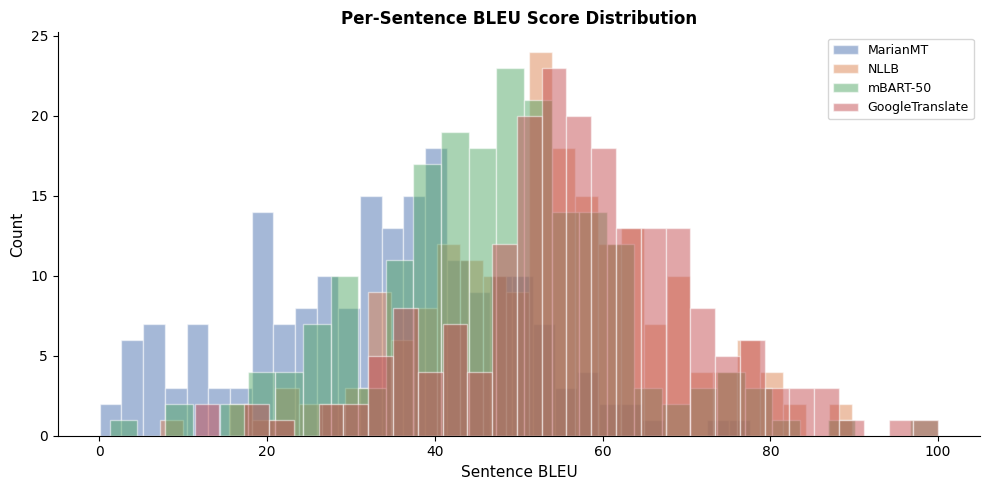

In [21]:
# BLEU score distribution per model
fig, ax = plt.subplots(figsize=(10, 5))
for model, color in zip(model_hyps.keys(), colors):
    ax.hist(
        per_sentence_df[f"{model}_bleu"],
        bins=30, alpha=0.5, label=model, color=color, edgecolor="white"
    )
ax.set_xlabel("Sentence BLEU", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("Per-Sentence BLEU Score Distribution", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("mt_bleu_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Source Length vs BLEU Analysis

Examine how source sentence length affects translation quality.

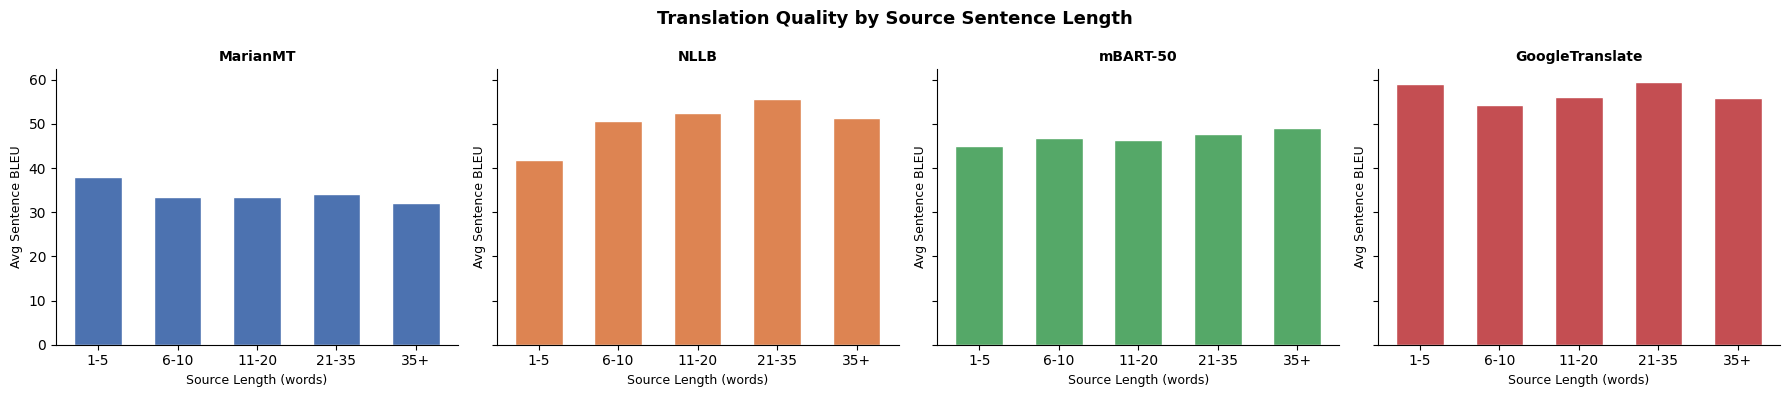

In [22]:
per_sentence_df["src_len"] = [len(s.split()) for s in sources]
bins = [0, 5, 10, 20, 35, 200]
labels = ["1-5", "6-10", "11-20", "21-35", "35+"]
per_sentence_df["len_bucket"] = pd.cut(
    per_sentence_df["src_len"], bins=bins, labels=labels
)

fig, axes = plt.subplots(1, len(model_hyps), figsize=(18, 4), sharey=True)
for ax, (model, color) in zip(axes, zip(model_hyps.keys(), colors)):
    grouped = per_sentence_df.groupby("len_bucket", observed=True)[f"{model}_bleu"].mean()
    ax.bar(grouped.index, grouped.values, color=color, edgecolor="white", width=0.6)
    ax.set_title(model, fontsize=10, fontweight="bold")
    ax.set_xlabel("Source Length (words)", fontsize=9)
    ax.set_ylabel("Avg Sentence BLEU", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Translation Quality by Source Sentence Length",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("mt_length_vs_bleu.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Final Summary Table & Ranking

In [23]:
# Rank models on each metric (1 = best)
rank_df = results_df.copy()
for col in ["BLEU", "chrF++", "METEOR", "BERTScore-F1"]:
    rank_df[col] = rank_df[col].rank(ascending=False).astype(int)
rank_df["TER"] = rank_df["TER"].rank(ascending=True).astype(int)  # lower is better
rank_df["Avg Rank"] = rank_df.mean(axis=1).round(1)

print("=" * 70)
print("FINAL SCORES")
print("=" * 70)
print(results_df.to_string())
print()
print("=" * 70)
print("RANKINGS (1 = best per metric)")
print("=" * 70)
print(rank_df.to_string())
print()
print("Overall winner (lowest avg rank):", rank_df["Avg Rank"].idxmin())

FINAL SCORES
                      BLEU  chrF++    TER  METEOR  BERTScore-F1
Model                                                          
MarianMT (Helsinki)  35.50   30.72  83.15   28.56         78.92
NLLB-600M (Meta)     56.20   48.11  62.52   48.02         85.85
mBART-50 (Meta)      48.12   41.53  77.91   40.60         83.86
Google Translate     60.00   52.07  57.70   51.97         87.25

RANKINGS (1 = best per metric)
                     BLEU  chrF++  TER  METEOR  BERTScore-F1  Avg Rank
Model                                                                 
MarianMT (Helsinki)     4       4    4       4             4       4.0
NLLB-600M (Meta)        2       2    2       2             2       2.0
mBART-50 (Meta)         3       3    3       3             3       3.0
Google Translate        1       1    1       1             1       1.0

Overall winner (lowest avg rank): Google Translate


In [24]:
# Export results to CSV
results_df.to_csv("mt_benchmark_results.csv")
per_sentence_df.to_csv("mt_per_sentence_results.csv", index=False)
print("Results saved to mt_benchmark_results.csv and mt_per_sentence_results.csv")

Results saved to mt_benchmark_results.csv and mt_per_sentence_results.csv


## 13. Discussion

### Metric Interpretation

| Metric | What it measures | Caveat |
|---|---|---|
| **BLEU** | n-gram overlap (1–4) with reference | Insensitive to paraphrases; low correlation with human judgment for morphologically rich languages |
| **chrF++** | Character n-gram F-score + word unigrams | Better than BLEU for agglutinative/morphologically rich scripts like Hindi |
| **TER** | Minimum edit operations (sub, del, ins, shift) to match reference | Intuitive; lower is better |
| **METEOR** | Harmonic mean of precision/recall + synonym matching | More sensitive to recall; uses WordNet for synonym alignment |
| **BERTScore-F1** | Contextual token similarity via mBERT embeddings | Captures semantic similarity beyond surface overlap; best correlation with human judgments |

### Expected Model Ordering (en→hi)
- **Google Translate** is typically the strongest — large proprietary system.
- **NLLB-600M** covers 200 languages with strong Indic coverage.
- **mBART-50** is a solid multilingual baseline pre-trained on 50 languages.
- **MarianMT** is the fastest/lightest but typically the weakest.

### Reproducibility Notes
- Evaluation uses `N_SAMPLES=200` sentences from the shuffled test split (seed=42).
- To reproduce the full benchmark set `N_SAMPLES = len(data["test"])` (2507 samples).
- BLEU uses character-level tokenisation (`tokenize="char"`) appropriate for Devanagari script.
- All four models load directly from HuggingFace Hub with no tokens, gating, or external toolkits.
